In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as px

In [2]:
import sys
print(sys.executable)

C:\Users\tanu\anaconda3\python.exe


In [3]:
#!{sys.executable} -m pip install seaborn

In [4]:
medical_df = pd.read_csv("medical.csv")
print(medical_df)


      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [5]:
sns.set_style("darkgrid")

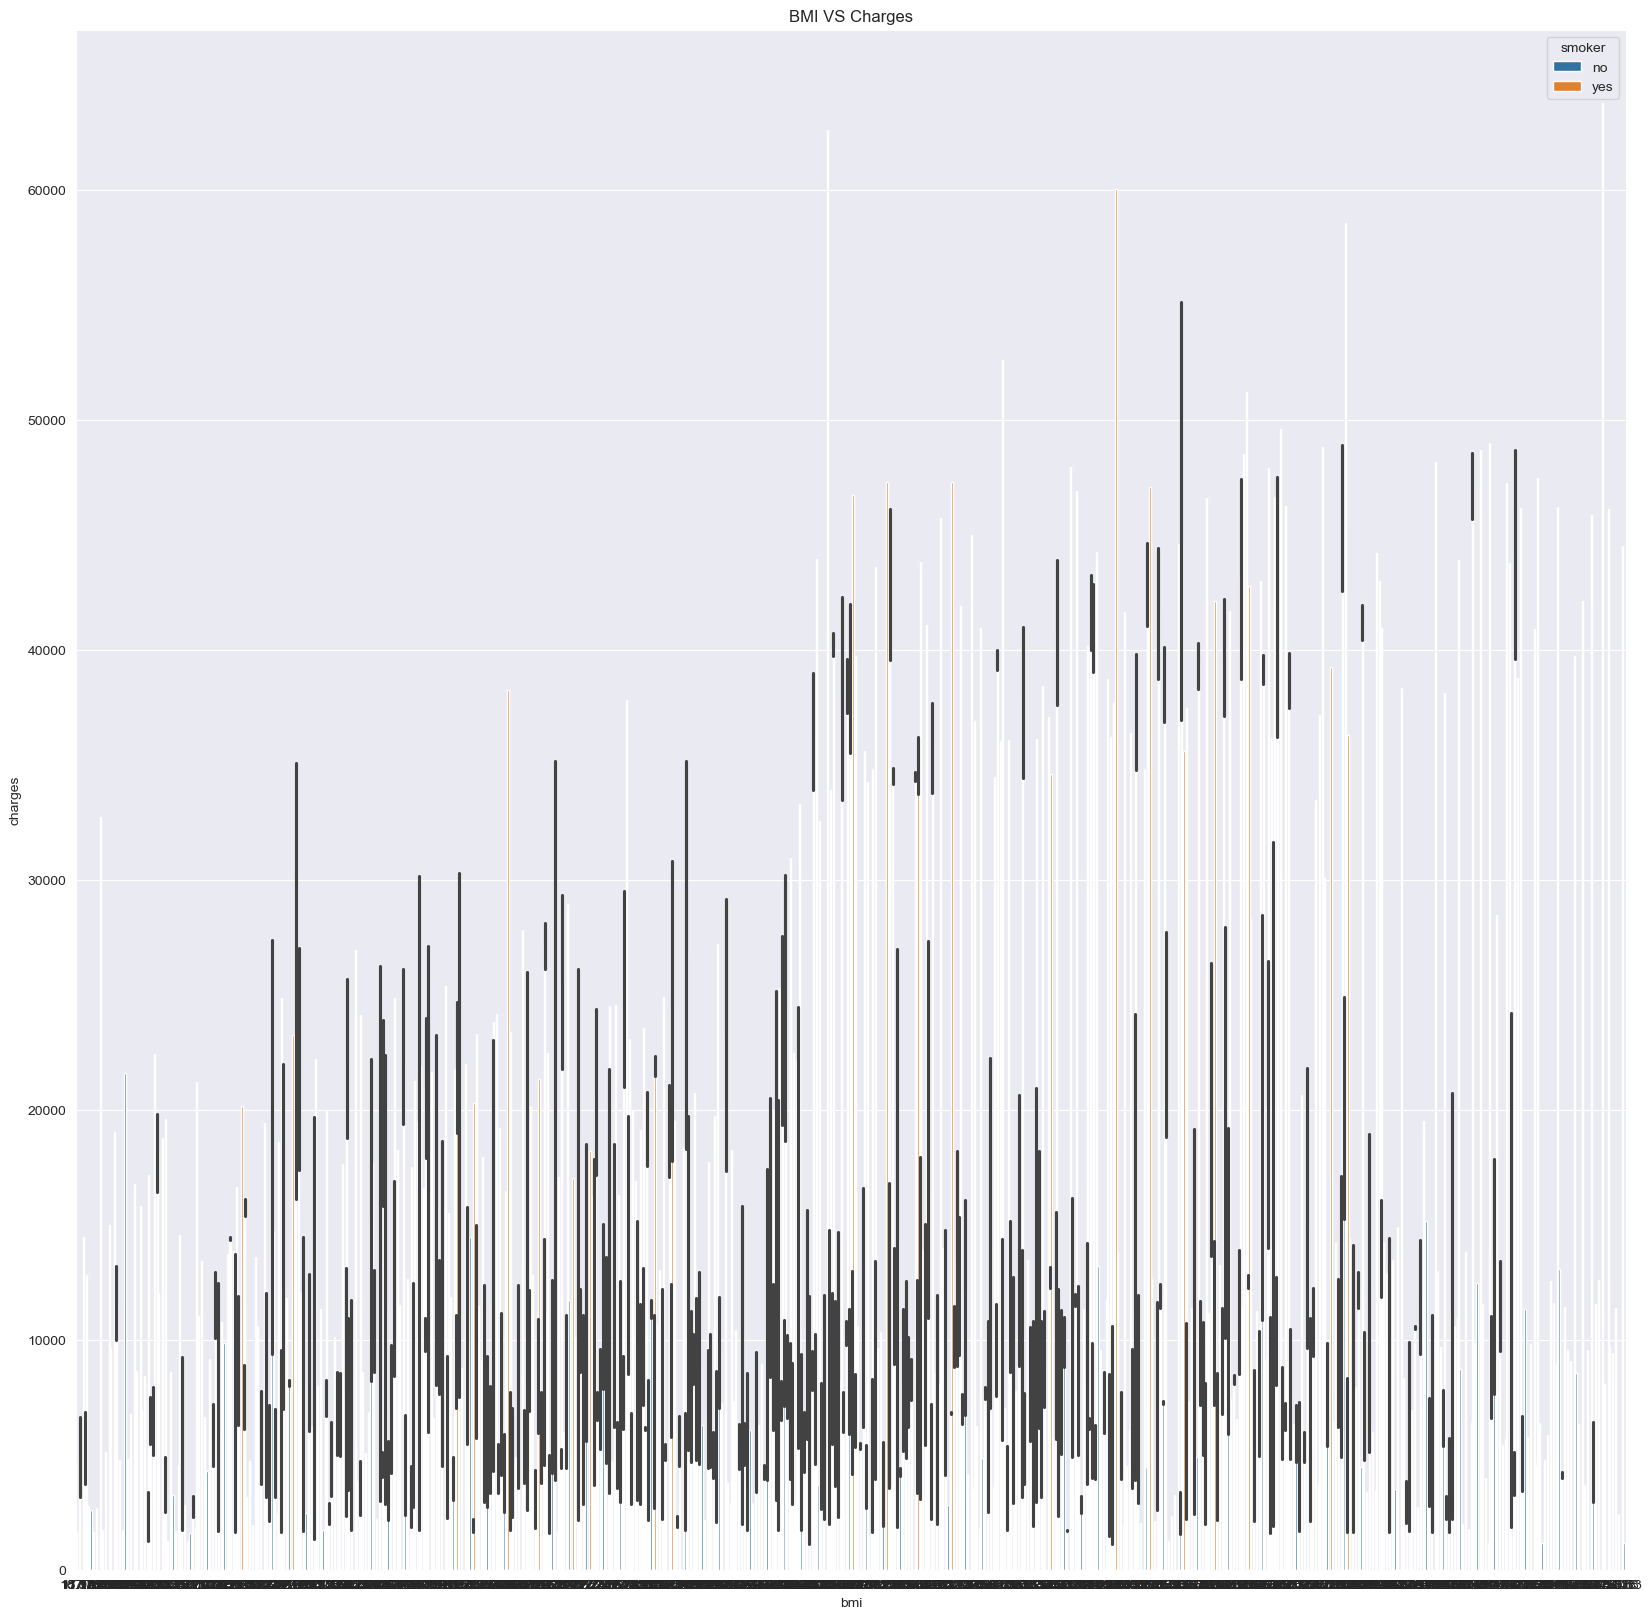

In [6]:
plt.figure(figsize=(20,20))
plt.title("BMI VS Charges")
sns.barplot(data = medical_df,x="bmi",y="charges",hue="smoker");

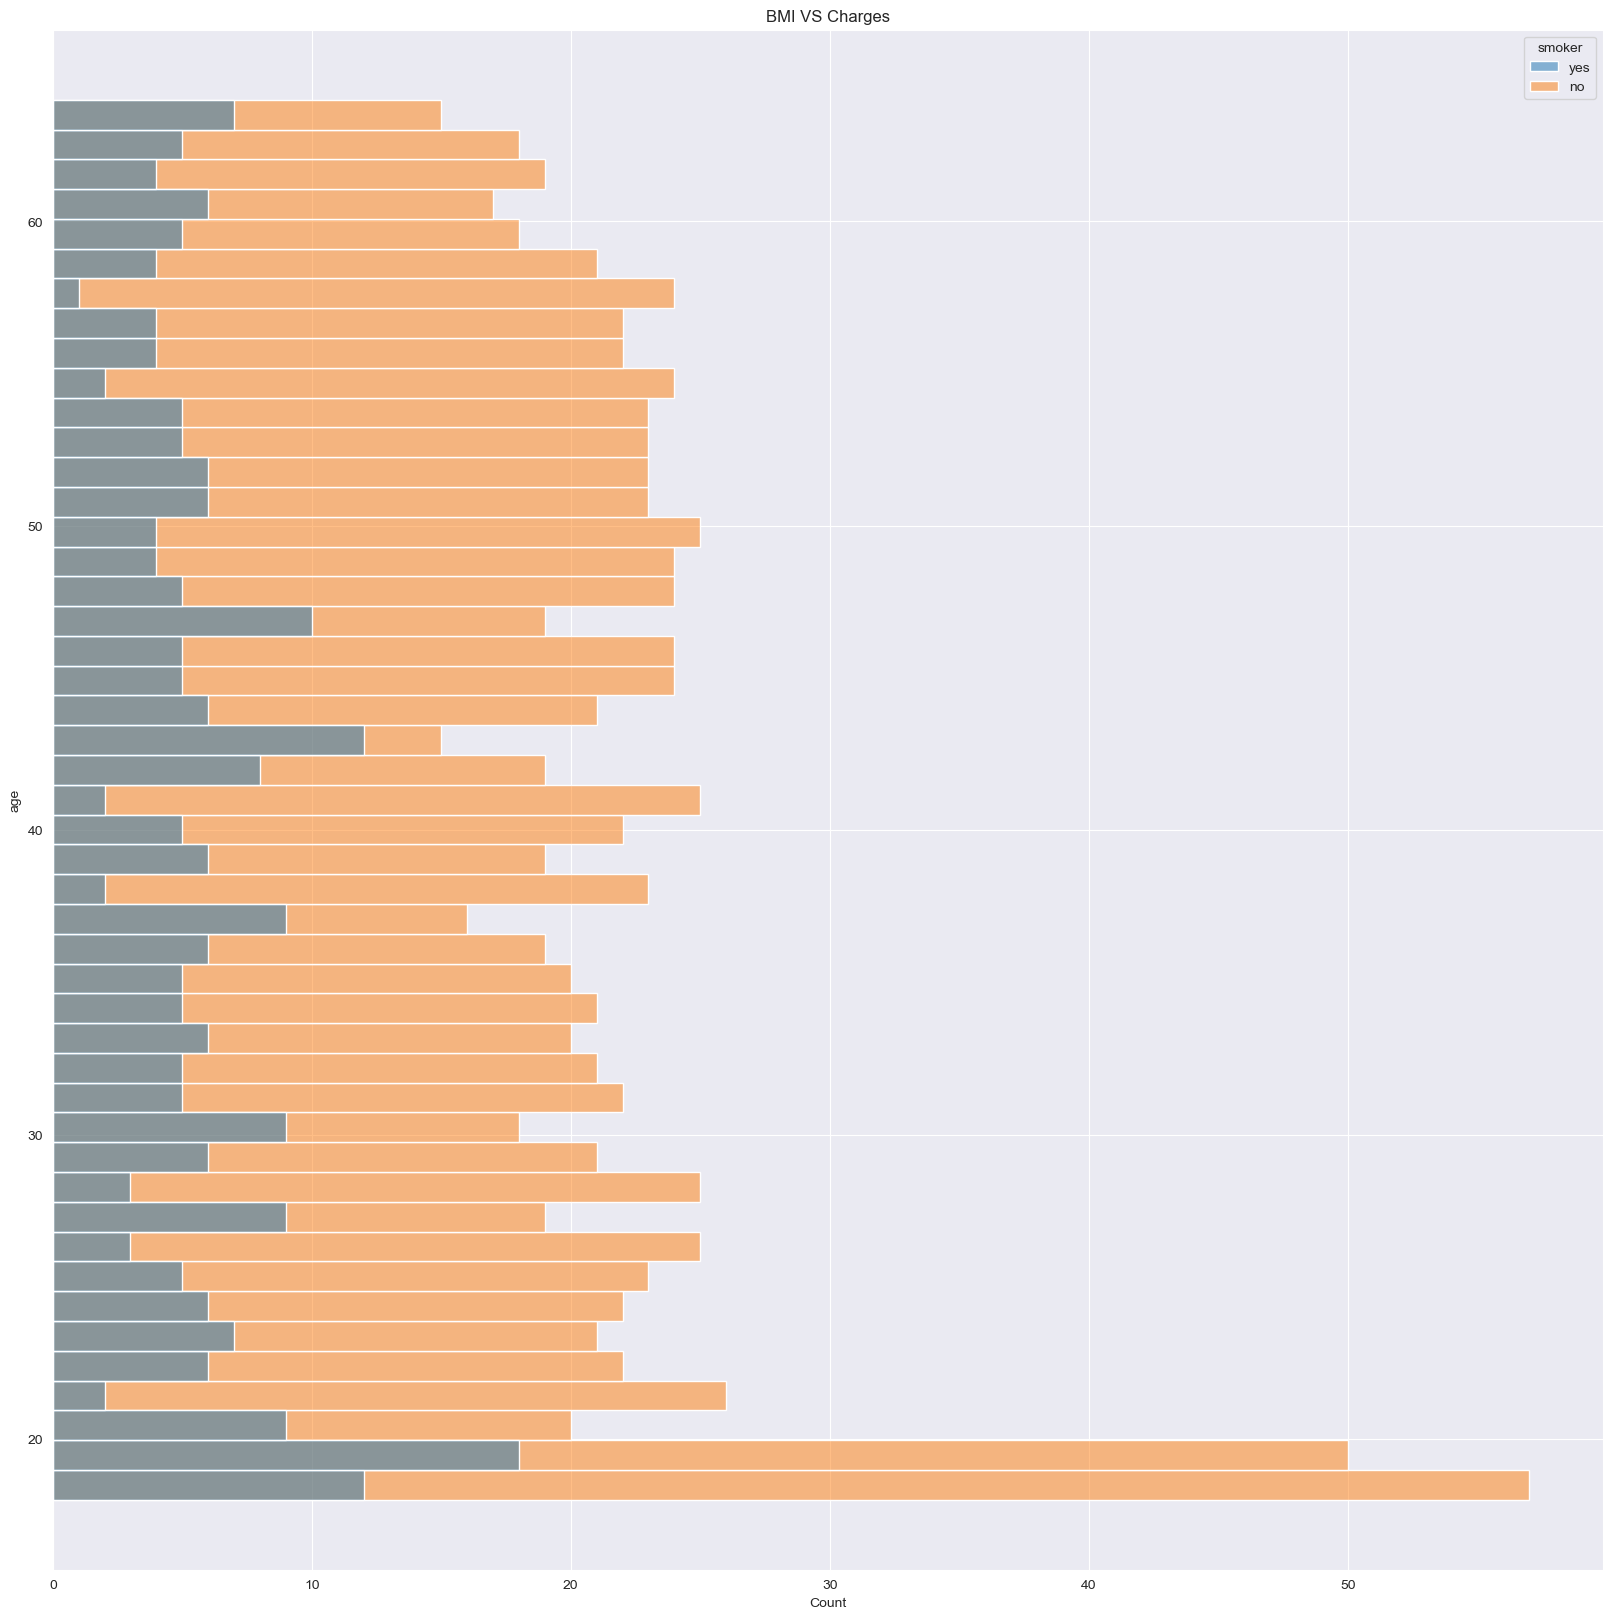

In [7]:
plt.figure(figsize=(20,20))
plt.title("BMI VS Charges")
sns.histplot(data=medical_df,y="age",hue = "smoker",bins = 47 );

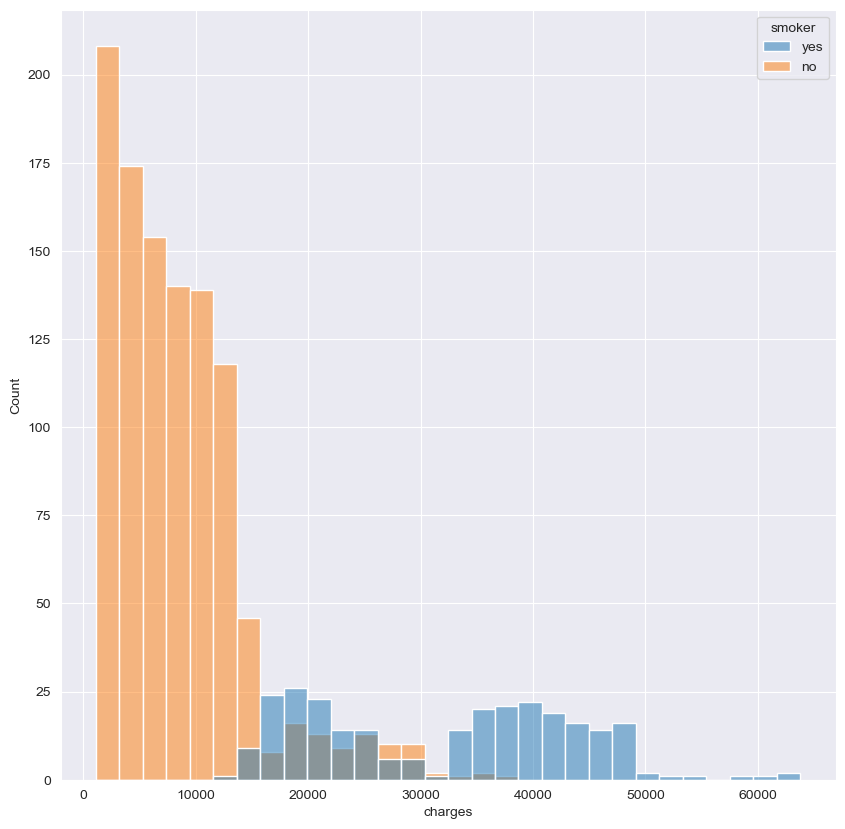

In [8]:
plt.figure(figsize=(10,10))
plt.title("")
sns.histplot(data = medical_df,x = "charges",hue = "smoker");


In [9]:
sns.set_style("darkgrid");

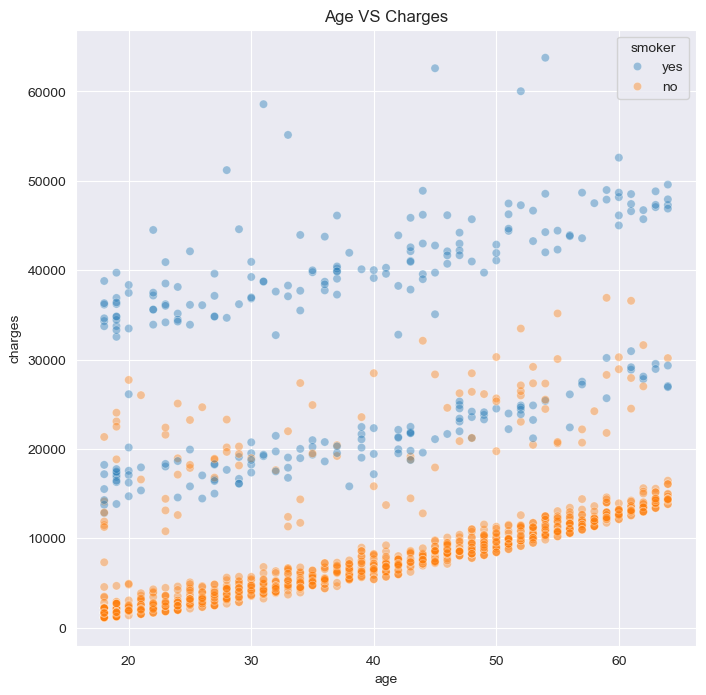

In [10]:
plt.figure(figsize=(8,8))
plt.title("Age VS Charges")
sns.scatterplot(data = medical_df,x="age",y="charges", hue="smoker",alpha=0.4);

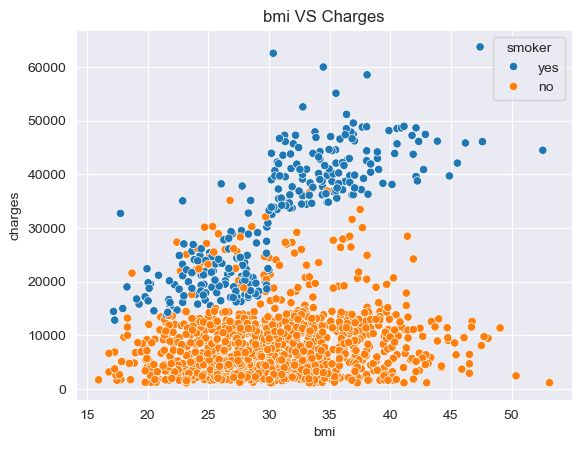

In [11]:
plt.title("bmi VS Charges")
sns.scatterplot(data = medical_df,x="bmi",y="charges",hue="smoker");

In [12]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


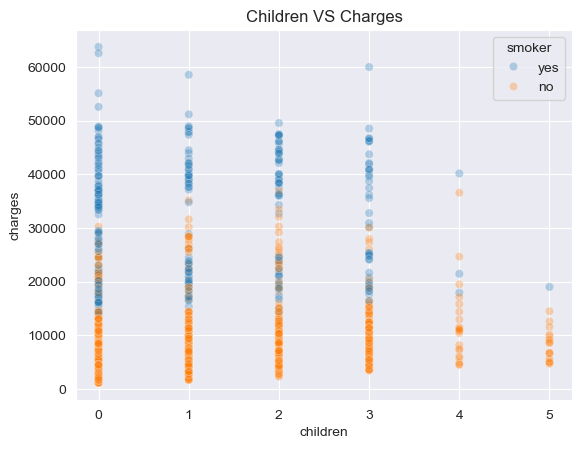

In [13]:
plt.title("Children VS Charges")
sns.scatterplot(data = medical_df,x="children",y="charges",hue="smoker",alpha=0.3);

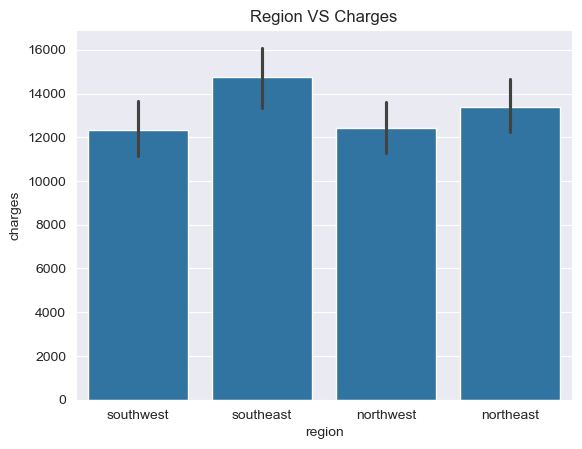

In [14]:
plt.title("Region VS Charges")
sns.barplot(data  =medical_df,x="region",y="charges");


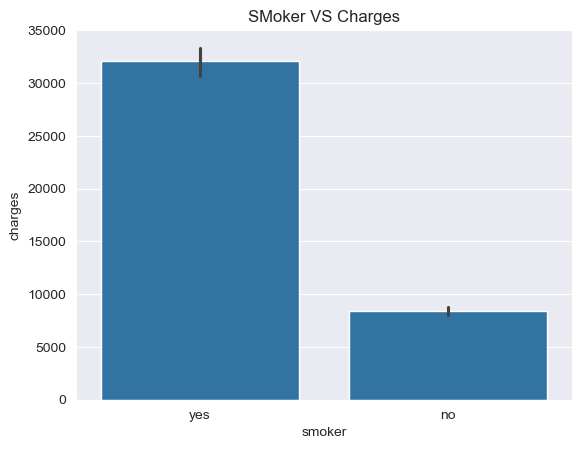

In [15]:
plt.title("SMoker VS Charges")
sns.barplot(data = medical_df,x="smoker",y="charges");

In [16]:
nonsmoker_df = medical_df[medical_df.smoker == "no"]
print(nonsmoker_df)

      age     sex     bmi  children smoker     region      charges
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
5      31  female  25.740         0     no  southeast   3756.62160
...   ...     ...     ...       ...    ...        ...          ...
1332   52  female  44.700         3     no  southwest  11411.68500
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500

[1064 rows x 7 columns]


In [17]:
from sklearn.metrics import root_mean_squared_error
def rmse(target,preds):
    return root_mean_squared_error(target,preds)

In [18]:
def estimate_charges(ages,w,b):
    return ages*w + b

In [19]:
estimate_charges(34,56,9)

1913

In [20]:
def predict(w,b):
    target = medical_df[["charges"]]
    inputs = medical_df[["age"]] 
    prediction = estimate_charges(inputs,w,b)
    plt.plot(inputs,prediction,)
    plt.scatter(inputs,target,alpha=0.3)
    plt.show()
    return rmse(target,prediction)
    

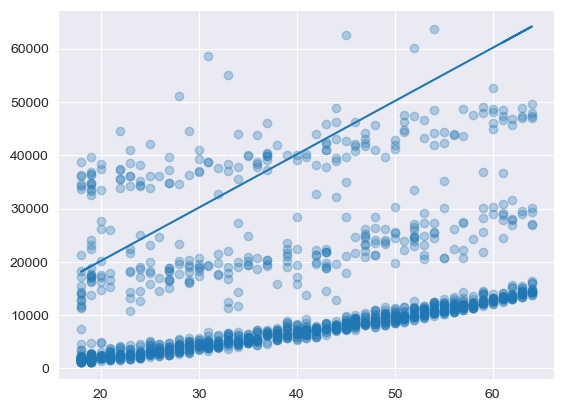

30374.88968904653

In [21]:
predict(1000,150)

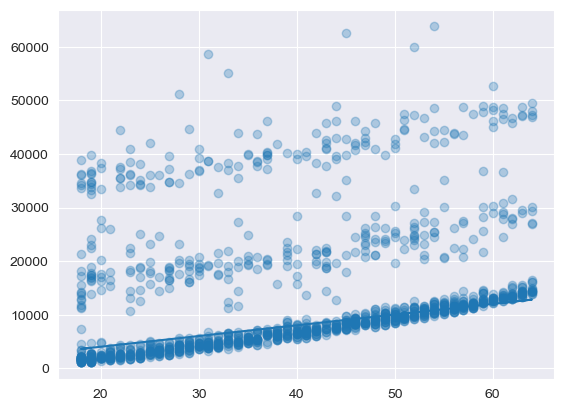

12768.399849498188

In [22]:
predict(200,50)

In [23]:
def rmse(targets,predicts):
   return np.sqrt(np.mean(np.square(predicts-targets)))
    

Training using  linear Regression

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
model = LinearRegression().fit(medical_df[["age"]],medical_df['charges'])
model.predict(medical_df[["age"]])

array([ 8062.61476073,  7804.89214207, 10382.11832874, ...,
        7804.89214207,  8578.05999807, 18886.96474474], shape=(1338,))

In [26]:
medical_df.charges

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [27]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [28]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [29]:
input_col = ["age","sex","bmi","children","smoker","region"]
target_col = "charges"

In [30]:
inputs = medical_df[input_col].copy()
target = medical_df[target_col].copy()


In [31]:

sm_code = {"yes":1,"no":0}
medical_df["smoker_code"] = medical_df.smoker.map(sm_code)
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.7872514304984772)

In [32]:
s_code = {"female":0,"male":1}
medical_df["sex_code"] = medical_df.sex.map(s_code)
medical_df.charges.corr(medical_df.sex_code)

np.float64(0.057292062202025415)

In [33]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.7872514304984772)

In [34]:
encoded_cols = ["northeast","northwest","southeast","southwest"]

#### Since the models can`t be trained over the categorical data ,so using onehotencoding converting into binary format 

In [36]:
from sklearn.preprocessing import OneHotEncoder

In [37]:
encoder = OneHotEncoder(handle_unknown = "ignore").fit(medical_df[["region"]])
medical_df[encoded_cols]=encoder.transform(medical_df[["region"]]).toarray()

In [38]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error


In [40]:
train_data = ["age","bmi","children","sex_code","smoker_code","northeast","northwest","southeast","southwest"]


In [41]:
x_input = medical_df[train_data]


In [42]:
numeric_cols = ["age" , "bmi","children"]

### Scaling down the numeric features to the range of -1 to 1

In [43]:
scaler = StandardScaler().fit(medical_df[numeric_cols])
medical_df[numeric_cols] = scaler.transform(medical_df[numeric_cols])

In [44]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,-1.438764,female,-0.453320,-0.908614,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,-1.509965,male,0.509621,-0.078767,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,-0.797954,male,0.383307,1.580926,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,-0.441948,male,-1.305531,-0.908614,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,-0.513149,male,-0.292556,-0.908614,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,male,0.050297,1.580926,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,-1.509965,female,0.206139,-0.908614,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,-1.509965,female,1.014878,-0.908614,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,-1.296362,female,-0.797813,-0.908614,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [45]:
model = LinearRegression().fit(x_input,target)
preds = model.predict(x_input)
print(preds)

[25293.7130284   3448.60283431  6706.9884907  ...  4149.13248568
  1246.58493898 37085.62326757]


In [46]:
rmse(target,preds)

np.float64(6041.6796511744515)

In [47]:
np.sqrt(mean_squared_error(preds,target))

np.float64(6041.6796511744515)

np.sqrt(36501893.00741544)

In [48]:
print(np.sqrt(36501893.00741544))

6041.6796511744515


In [49]:
model.coef_.tolist()

[256.856352537348,
 339.1934536108374,
 475.50054514913023,
 -131.31435939511093,
 23848.534541912843,
 587.0092350283268,
 234.04533560368375,
 -448.01281435949943,
 -373.0417562725086]

##### Checking the importance given to each columns  

In [50]:
features_df = pd.DataFrame({
    "features" : np.append(train_data,1),
    "weights" : np.append(model.coef_,model.intercept_)
})
print(features_df)

      features       weights
0          age    256.856353
1          bmi    339.193454
2     children    475.500545
3     sex_code   -131.314359
4  smoker_code  23848.534542
5    northeast    587.009235
6    northwest    234.045336
7    southeast   -448.012814
8    southwest   -373.041756
9            1 -12525.547811


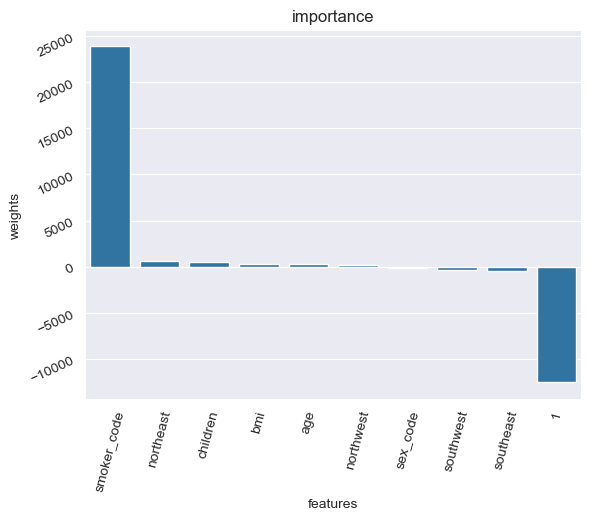

In [51]:
plt.title("importance")
plt.yticks(rotation=25)
plt.xticks(rotation = 75)
sns.barplot(data=features_df.sort_values("weights",ascending=False),x="features",y="weights");


In [52]:
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestRegressor

##### Trying the different models which fits into the data 

In [57]:
df = DecisionTreeRegressor(random_state = 42,max_depth = 10).fit(x_input,target)
preds = df.predict(x_input)
print(preds)

[16894.45471875  1720.78182     4735.15836    ...  1716.38401
  2191.41352857 29072.8691375 ]


In [58]:
medical_df.charges

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [59]:
loss = np.sqrt(mean_squared_error(preds,target))
print(loss)

2213.545352034041


In [60]:
rmse(target,preds)

np.float64(2213.545352034041)

In [61]:
df.tree_.max_depth

10

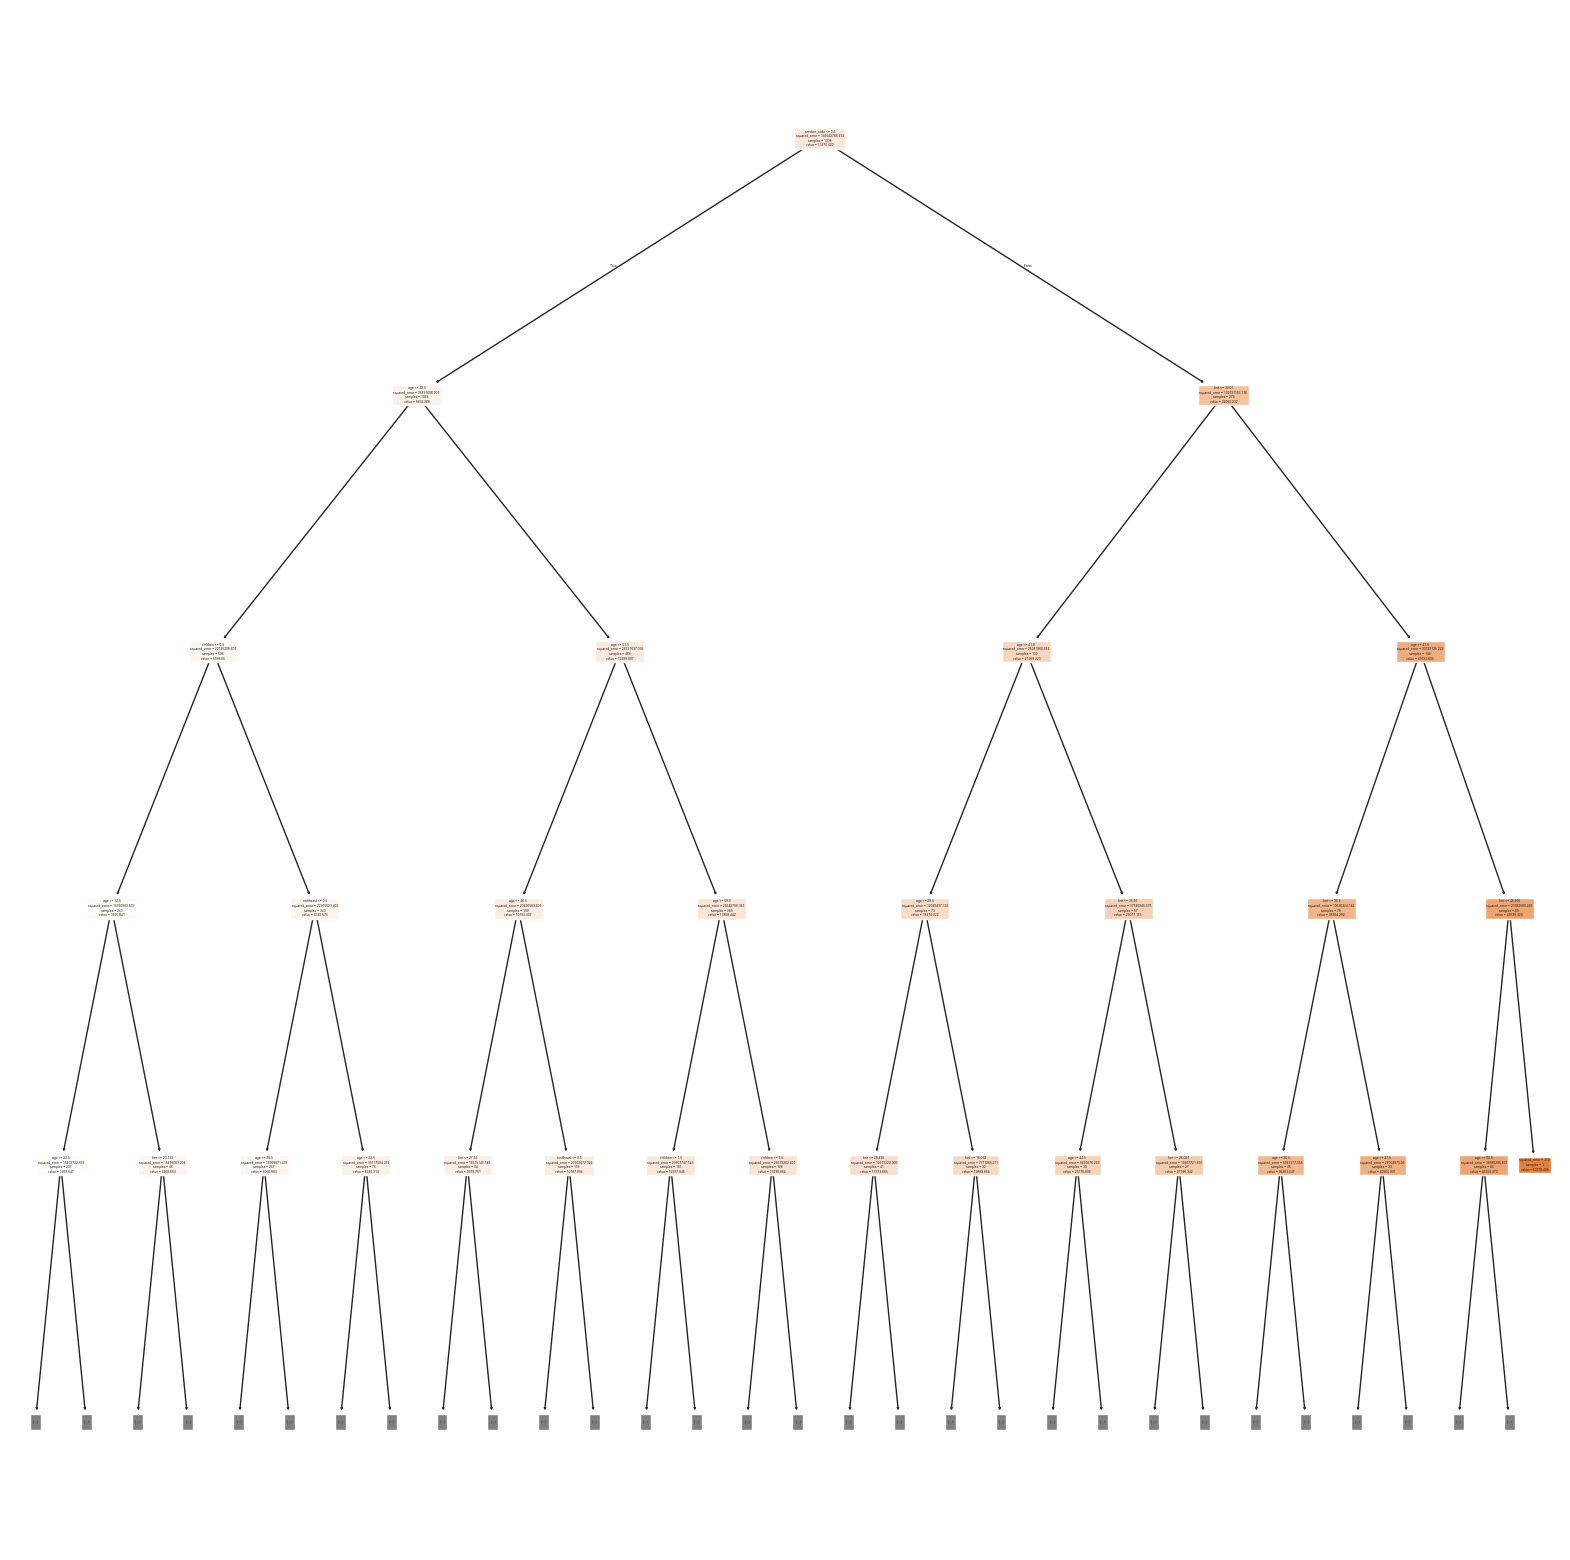

In [62]:
plt.figure(figsize=(20,20))
plot_tree(df,feature_names=train_data,max_depth=4,filled=True);

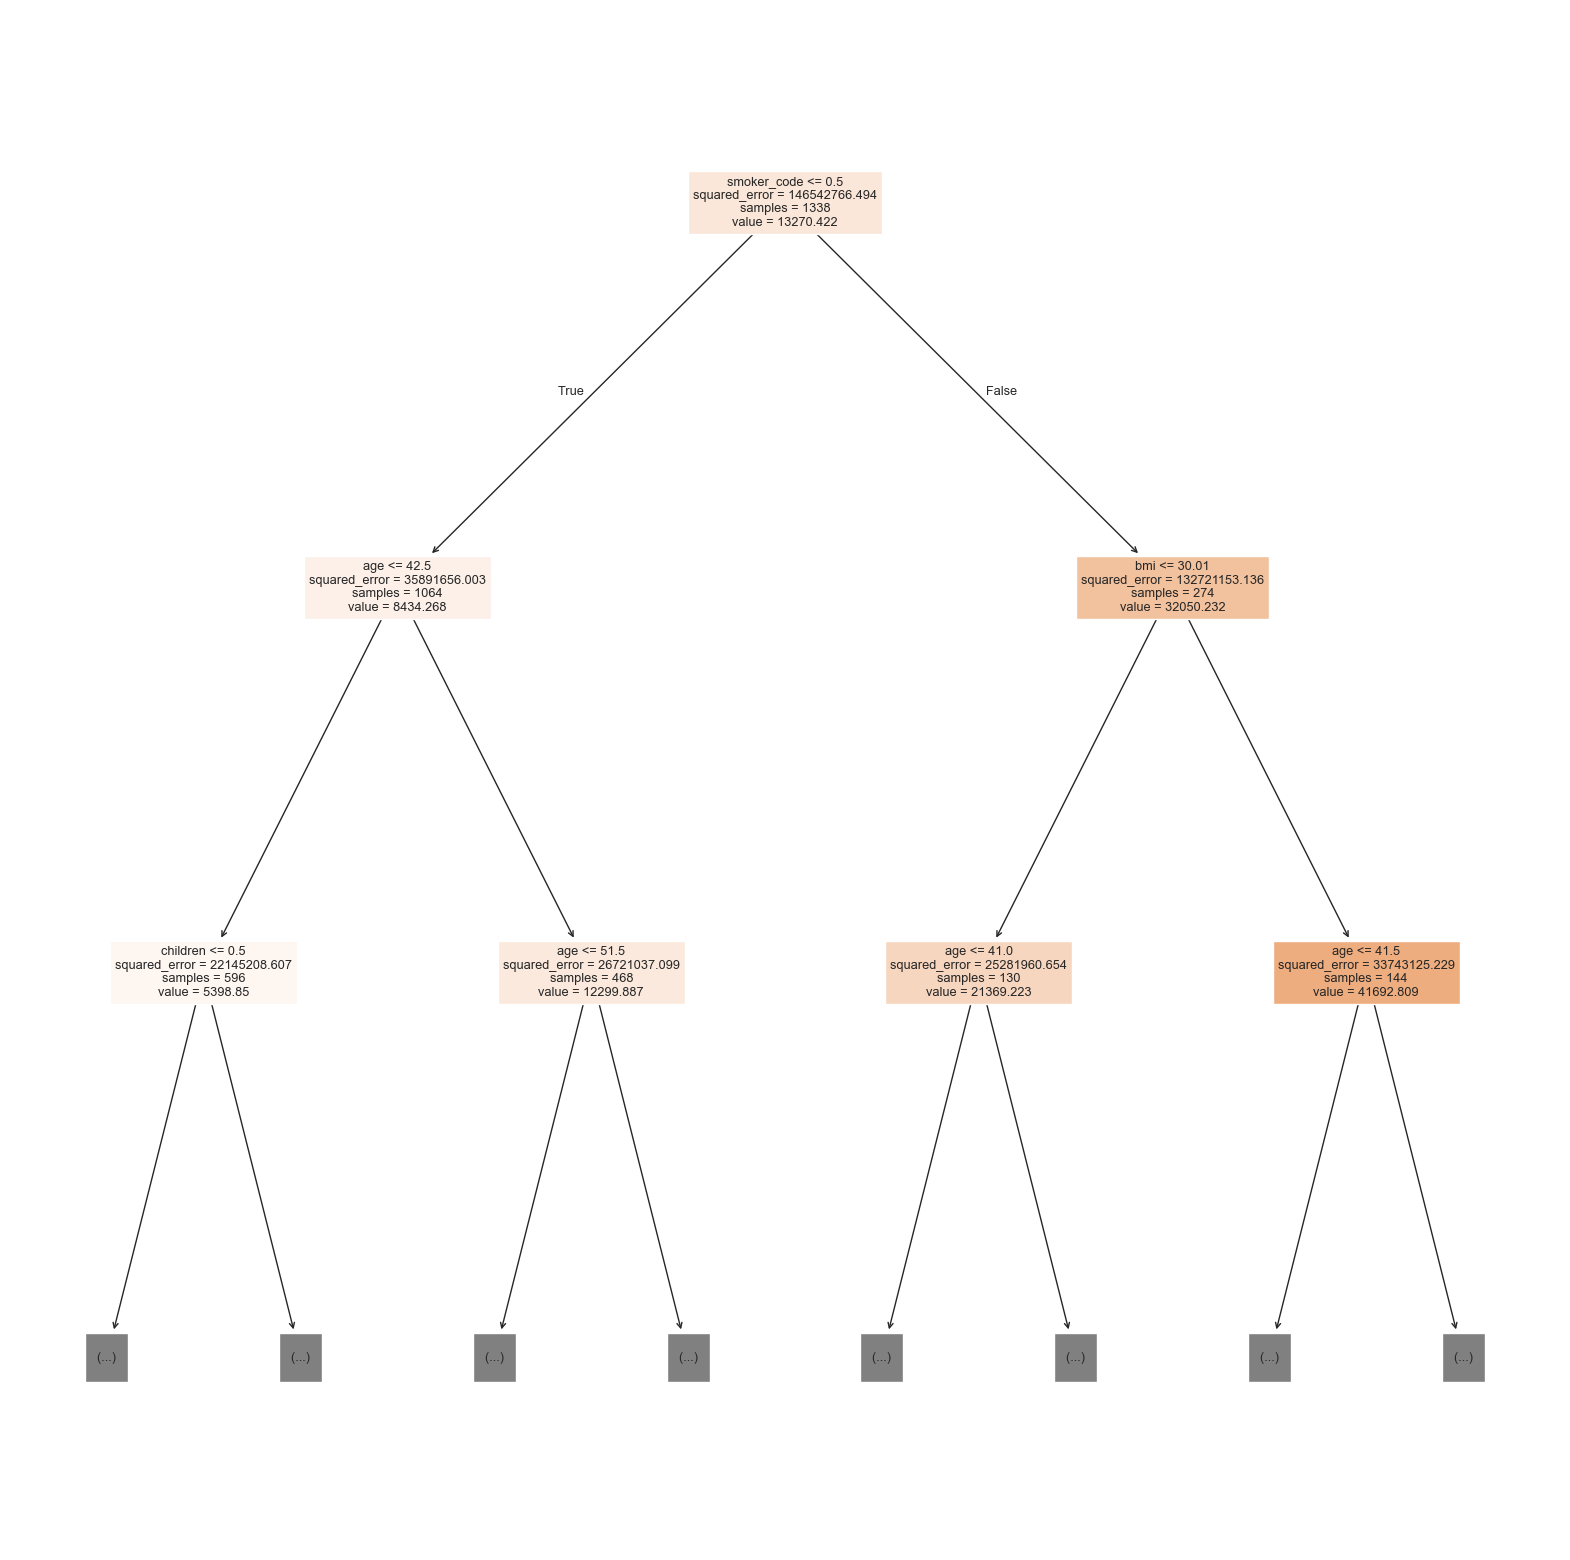

In [63]:
plt.figure(figsize=(20,20))
plot_tree(df,feature_names=train_data,max_depth=2,filled=True);

#### Prdicting the medical annual insurance of a new one whoever wish

In [64]:
def predict_input(single_input):
    input_df = pd.DataFrame([single_input])
    input_df[numeric_cols] = imputer.transform(input_df[numeric_cols])
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    x_input = np.concatenate((numeric_cols , encodede_cols),axis = 1)
    preds = df.predict(x_input)
    print(preds)